In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

In [2]:

σ = 0.0 # how much noise is added to the operator (now a *relative* noise level, see the Λn cell — try e.g. 0.05-0.2 to actually see an effect; 0.0 means no noise)
# Steers prox operators:
ρ_obj = 0.0 # for prox operator

num_modes = 255

255

In [3]:
img = load("../reconstructions/1096.jpg")
img_f = img .|> Float64
img_f .-= 0.5
img_f .*= 2.0
img_f .= exp.(img_f) # Just an idea maybe EIT reconstruction is easier with this.

150×150 Matrix{Float64}:
 1.38471   1.39561   1.4066    1.4066    …  1.89499   1.88019   1.88019
 1.41768   1.42884   1.44009   1.44009      1.90992   1.90992   1.90992
 1.44009   1.45143   1.46286   1.46286      1.92495   1.92495   1.92495
 1.46286   1.47438   1.48599   1.48599      1.92495   1.92495   1.92495
 1.48599   1.49769   1.50948   1.50948      1.94011   1.94011   1.94011
 1.47438   1.48599   1.49769   1.49769   …  1.97078   1.97078   1.97078
 1.44009   1.45143   1.46286   1.46286      1.9863    1.9863    1.9863
 1.44009   1.45143   1.46286   1.46286      1.97078   1.9863    1.9863
 1.46286   1.46286   1.47438   1.48599      2.01771   2.00194   1.9863
 1.47438   1.48599   1.48599   1.49769      2.00194   2.00194   1.9863
 ⋮                                       ⋱                      
 0.367879  0.382593  0.388641  0.407368     0.388641  0.373696  0.388641
 0.394786  0.437162  0.385605  0.385605     0.394786  0.367879  0.373696
 0.385605  0.417066  0.42366   0.417066     0.39

In [4]:
itp = interpolate_array_2D(Float64.(img_f))

#interpolate_array_2D##0 (generic function with 1 method)

In [5]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));

In [6]:
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,2,3,∂Ω)

FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.0076

In [7]:
cond_vec = project_function_to_fem(fe, itp; space=:σ)
cond_vec .= min.(max.(cond_vec, 1e-6), 2.8)

16129-element Vector{Float64}:
 1.382851515215743
 1.4461036450302287
 1.4705024871741166
 1.4057674569022744
 1.4211286105875955
 1.4606730403950126
 1.44543334978488
 1.397121578047869
 1.435236623086088
 1.4832646487729524
 ⋮
 0.39147516456015996
 0.37949624645158764
 0.3787253106923044
 0.3737451816310125
 0.3744207581314939
 0.3743052140613185
 0.37861648083896504
 0.37733507593840276
 0.38252574778169773

In [8]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [9]:
# G must be mean zero on the boundary (Neumann data integrates to 0);
# `down`/`up` batch over columns, so this normalizes all modes at once.
mean_zero_boundary(G_boundary) = G_boundary .- Statistics.mean(G_boundary, dims=1)

mean_zero_boundary (generic function with 1 method)

In [10]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:num_modes+1
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i-1] = assemble_rhs_func(fe, itp)
end
G = reduce(hcat, [rhs_dict[i] for i in 1:num_modes])
G = fe.up(mean_zero_boundary(fe.down(G)))

16129×255 Matrix{Float64}:
  0.000935326   6.25191e-21  0.000935326  …  -1.74317e-19   0.000661344
  0.000935036   2.33183e-5   0.000934164      2.25898e-5   -0.000661407
  0.0           0.0          0.0              0.0           0.0
  0.000935036  -2.33183e-5   0.000934164     -2.25898e-5   -0.000661407
  0.00187037    2.33184e-5   0.00186951       2.33184e-5   -2.10274e-5
  0.0           0.0          0.0          …   0.0           0.0
  0.0           0.0          0.0              0.0           0.0
  0.00187037   -2.33184e-5   0.00186951      -2.33184e-5   -2.10274e-5
  0.0           0.0          0.0              0.0           0.0
  0.000934164   4.66221e-5   0.00093068      -4.51665e-5    0.000661344
  ⋮                                       ⋱                
  0.0           0.0          0.0          …   0.0           0.0
 -0.000935036  -2.33183e-5   0.000934164     -2.25898e-5   -0.000661407
  0.0           0.0          0.0              0.0           0.0
 -0.0018692    -6.99407e-5 

In [11]:
G_in = G
fbm_true = FerriteBlockMode(cond_vec, G_in, fe; block=true)

FerriteBlockMode(ModularEIT.BlockLAssembler(9, [0.2402271535551934 -0.012994888716472794 … -0.07636483214313623 -0.137366901916561; -0.012994888716472794 0.24286388936529998 … 0.042975285839043705 -0.13916186681270395; … ; -0.07636483214313623 0.042975285839043705 … 0.7461694739155396 -0.40544153700504315; -0.137366901916561 -0.13916186681270395 … -0.40544153700504315 2.176952383386513]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0  …  1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0], sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 1  …  16129, 15868, 15872, 15874, 16122, 16123, 16126, 16127, 16128, 16129], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2  …  16128, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129], [0.8721811565057925, -0.0477859222081613, -0.03169795418931451, -0.047461881614715234, -0.28314221307968646, 0.15798138993258948, 0.15671962432315667, -0.27997060067392726, -0.4968235989957337, -0.0477859222081613  …  -0.4072295809345175, -0.137366901916561, -0.13916186681270395, -0.41

In [12]:
F = copy(fbm_true.F)
F = mean_zero_boundary(F)
Λ = F * pinv(fe.down(G))
Λ = 0.5 .* (Λ' + Λ) # It should be self adjoint, so I make it self adjoint. (It basically is up to small numerical errors)
# This is supposed to be a synthetic EIT reconstruction, so I should somehow add noise to my reconstruction. I was thinking about adding symmetric random noise matrix to Λ or Λ⁻¹. Please do:
# NOTE: the line below was previously `Λn = Λ + σ * ` — incomplete syntax (nothing after `*`), which is why this cell couldn't run.
# Two things worth fixing beyond that:
#   1. Λ is symmetric (you just enforced that above), so the noise should be symmetric too —
#      an unsymmetrized `randn` perturbation adds a skew component that isn't physical and will
#      show up as spurious asymmetry in Λn (and later mess with svd_on_modes/reconstruction).
#   2. σ should act as a *relative* noise level (this matches how σ is described in the parameter
#      cell, and is the usual EIT convention), not an absolute one — otherwise the same σ means
#      wildly different things depending on the overall scale of Λ. Scaling by norm(Λ)/norm(Ε)
#      makes `σ * norm(Λ) * Ε/norm(Ε)` have Frobenius norm ≈ σ * norm(Λ), i.e. σ=0.15 ≈ 15% relative noise.
Ε = randn(size(Λ))
Ε = 0.5 .* (Ε + Ε') # symmetrize the noise itself, not just Λ + noise
Λn = Λ + σ * (norm(Λ) / norm(Ε)) * Ε
Λn = 0.5 .* (Λn + Λn') # re-symmetrize in case of floating point round-off


504×504 Matrix{Float64}:
  1.64262    0.712494   0.712639  …  -0.221603  -0.322     -0.322021
  0.712494   1.12312    0.786589     -0.217669  -0.316737  -0.316757
  0.712639   0.786589   1.13265      -0.217754  -0.316848  -0.316869
  1.71833    1.42185    1.16083      -0.335515  -0.433556  -0.4336
  1.71981    1.16059    1.42773      -0.335584  -0.433635  -0.43368
  0.702051   0.610996   0.618514  …  -0.214791  -0.312626  -0.312646
  1.03573    1.30512    1.05358      -0.330099  -0.426914  -0.426957
  0.534188   0.594456   0.547978     -0.211575  -0.308197  -0.308216
  0.925581   0.895907   0.87013      -0.325288  -0.420925  -0.420967
  0.485625   0.47576    0.471677     -0.208352  -0.303724  -0.303742
  ⋮                               ⋱                        
 -0.206261  -0.202559  -0.202641  …   1.63579    2.52108    2.66143
 -0.301205  -0.296263  -0.296372      2.3176     3.10831    3.19791
 -0.211318  -0.207538  -0.207622      2.25925    3.14252    3.01974
 -0.308182  -0.30313   -

In [13]:

F, G, Σ = svd_on_modes(Λn,num_modes)

# svd_on_modes already returns G projected onto the boundary basis (fe.m rows),
# so it must not be passed through fe.down again -- just re-normalize and lift.
F = mean_zero_boundary(F) # Don't know if this is necessary
G = fe.up(mean_zero_boundary(G))

16129×255 Matrix{Float64}:
 -0.0134724  -0.0413396  -0.0140062  0.0707338  …  -3.20322e-6  -7.90692e-7
 -0.0132563  -0.0403286  -0.013701   0.0682054     -4.69616e-6   1.03615e-5
  0.0         0.0         0.0        0.0            0.0          0.0
 -0.0132581  -0.0403626  -0.013706   0.0682309     -4.6361e-6    2.14918e-6
 -0.0180466  -0.0584127  -0.0190097  0.0957314      3.63813e-6   7.05272e-6
  0.0         0.0         0.0        0.0        …   0.0          0.0
  0.0         0.0         0.0        0.0            0.0          0.0
 -0.0180485  -0.0584334  -0.0190133  0.0957511      3.73622e-6  -2.72736e-7
  0.0         0.0         0.0        0.0            0.0          0.0
 -0.0130918  -0.0395018  -0.013454   0.0661751     -3.81678e-6  -1.29347e-5
  ⋮                                             ⋱               
  0.0         0.0         0.0        0.0        …   0.0          0.0
  0.105671    0.0538216  -0.0665871  0.0371213     -3.22945e-6  -6.26379e-6
  0.0         0.0         0.0  

In [14]:
fbm = FerriteBlockMode(F, G, fe)

FerriteBlockMode(ModularEIT.BlockLAssembler(9, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0  …  1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0], sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 1  …  16129, 15868, 15872, 15874, 16122, 16123, 16126, 16127, 16128, 16129], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2  …  16128, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 16129, 16129), sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 16130  …  16112, 16114, 16116, 16118, 16120, 16122, 16124, 16126, 16127, 16128], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  16130, 16130, 16130, 16130, 16130, 16130, 16130, 16130, 16130, 16130], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 16130, 16130), [-1.5878574505622207 -3.255596903638644 … -1.169826816873593e-6 -2.829165618979354e-7; 

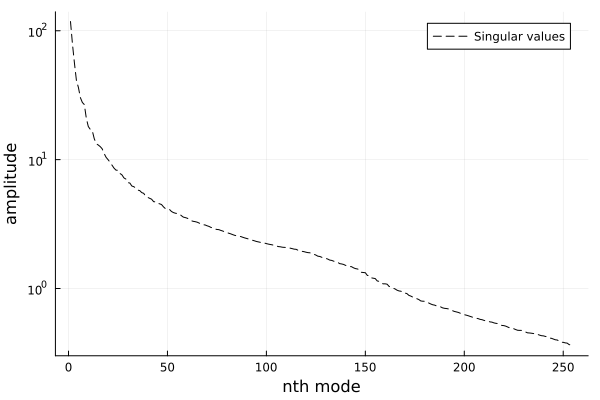

print device already activated


In [34]:
using Plots
p = plot(
    #1:10, Σ[1:10];
    1:length(Σ), Σ;
    yscale = :log10,
    xlabel = "nth mode",
    ylabel = "amplitude",
    color = :black,
    linestyle = :dash,
    label = "Singular values",
)

In [35]:
# Σ are singular values of Λn, i.e. the response gain ‖Λn v‖ for *unit-norm* v
# (Gnew's columns are unit norm by construction in svd_on_modes). fbm_true.F's
# columns are the response to the raw Fourier currents fe.down(G_in), which are
# NOT unit norm after going through assemble_rhs_func/mean_zero_boundary — so the
# raw column norms of fbm_true.F live on a different scale than Σ. Dividing by the
# input norm (in the same fe.m-dim Euclidean space Λ's SVD is computed in) turns FT
# into a gain ‖F_i‖/‖g_i‖, directly comparable to Σ.
FT = vec(sqrt.(sum(abs2, fbm_true.F; dims=1))) ./ vec(sqrt.(sum(abs2, fe.down(G_in); dims=1)))

255-element Vector{Float64}:
 84.88780254171549
 69.52368425657438
 82.50155659041766
 34.9003666895607
 49.26522552626428
 46.18188367048044
 38.1551117237553
 24.21734626042473
 29.00424758272223
 28.722565196087476
  ⋮
  1.1938927670355275
  1.1625214871187306
  1.1606523651161642
  1.1942490566326198
  1.4256932188822744
  0.9492437531921198
  1.2032483547889181
  1.146384425165598
  1.1747469790925231

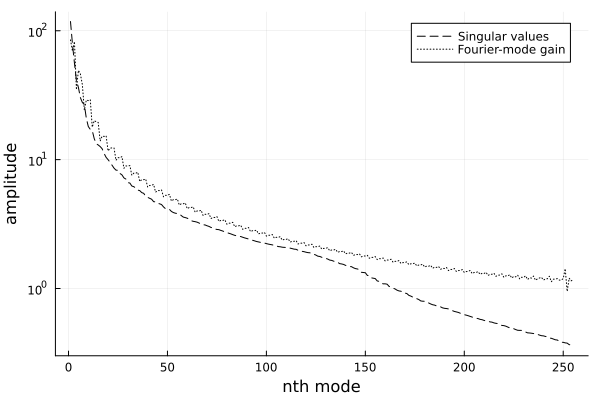

In [36]:
# FT is now scaled as a per-mode gain (‖F_i‖/‖g_i‖), same units as the
# singular values Σ, so both curves sit on the same plot.
plot!(
    p,
    #1:10, FT[1:10];
    1:length(FT), FT;
    color = :black,
    linestyle = :dot,
    label = "Fourier-mode gain",
)

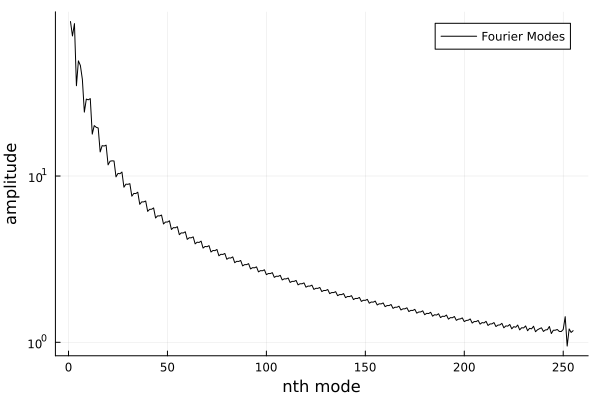

In [21]:
pf = plot(
    #1:10, Σ[1:10];
    1:length(FT), FT;
    yscale = :log10,
    xlabel = "nth mode",
    ylabel = "amplitude",
    color = :black,
    #linestyle = :dash,
    label = "Fourier Modes",
)

In [37]:
savefig(pf, "fourier_modes.svg")
savefig(p, "singular_values.svg")

"/home/daniel/Code/ModularEIT.jl/notebooks/block/singular_values.svg"

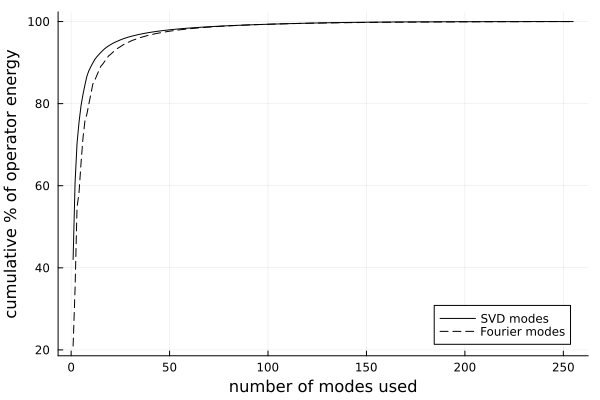

In [29]:
# Cumulative fraction of the operator's (Frobenius) energy captured by using
# the first k modes, for both bases.
#   - Σ.^2 sums to ‖Λn‖_F² exactly: svd_on_modes takes the top `num_modes`
#     singular values of the full svd, and Λn = F*pinv(fe.down(G)) has rank
#     ≤ num_modes by construction, so nothing is left outside this truncation.
#   - The Fourier basis is only *roughly* orthogonal (per your note), so
#     ∑ᵢ‖F_true,i‖² is only an approximate Parseval decomposition of the
#     operator's energy — each curve is normalized to its own total, so this
#     compares how efficiently each basis concentrates energy into its first
#     k modes, not their absolute totals against each other.
svd_energy = Σ .^ 2
fourier_energy = vec(sum(abs2, fbm_true.F; dims=1))

cum_svd = cumsum(svd_energy) ./ sum(svd_energy) .* 100
cum_fourier = cumsum(fourier_energy) ./ sum(fourier_energy) .* 100

p2 = plot(
    1:length(cum_svd), cum_svd;
    xlabel = "number of modes used",
    ylabel = "cumulative % of operator energy",
    color = :black,
    label = "SVD modes",
    legend = :bottomright,
)
plot!(
    p2,
    1:length(cum_fourier), cum_fourier;
    color = :black,
    linestyle = :dash,
    label = "Fourier modes",
)

In [30]:
savefig(p2, "operator_energy.svg")

"/home/daniel/Code/ModularEIT.jl/notebooks/block/operator_energy.svg"

In [19]:
#Either this
f, ∂f =  create_block_f∂f(fbm, fe; nmodes=25, block=true, gn=true, λ=1e-4)
prox_obj = create_prox_linesearch(f,∂f,ρ_obj)

(::ModularEIT.var"#prox#90"{Float64, ModularEIT.var"#prox#87#91"{ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}, ModularEIT.var"#57#58"{Int64, Bool, Float64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}, Base.RefValue{Bool}, Base.RefValue{Union{Nothing, Vector{Float64}}}, Base.RefValue{Union{Nothing, Vector{Float64}}}}}, Bool, Nothing, Float64, Float64, Int64}) (generic function with 2 methods)

In [ ]:
#Or this
f, ∂f =  create_block_f∂f(fbm, fe; nmodes=25, block=true, gn=false)
prox_obj = create_proximal_gradient_step(f,∂f,ρ_obj, fe.n_σ, maxiter= 1500)

In [ ]:
σ₁ = ones(fe.n_σ)
# I wonder why I can't initialize it with an exp(randn(fe.n_σ)). It seems that this will not converge... or just get stuck at the beginning.

In [ ]:
# NOTE: this was commented out, so σᵢ was never defined — the σ_img cell below would
# error with `UndefVarError: σᵢ`. Uncommented so the reconstruction actually runs.
#σᵢ, err, _ = prox_obj(σ₁)

In [ ]:
σ_img = log.(reshape(evaluate_at_points(ph, fe.dh_σ, σᵢ), (64, 64)))

In [ ]:
σ_img = Gray.(((σ_img) .*0.5) .+0.5)

In [ ]:
#save("linesearch_25_unregularized.png", map(clamp01nan, σ_img))

In [ ]:
# cond_vec lives on the σ-space (fe.dh_σ), not the u-space (fe.dh) — must
# evaluate against fe.dh_σ to read the conductivity image back out.
cond_img = reshape(evaluate_at_points(ph, fe.dh_σ, cond_vec), (64, 64))
cond_img = Gray.(log.(cond_img) .*0.5 .+0.5)

In [ ]:
#save("original.png", map(clamp01nan, cond_img))

In [ ]:
Λ⁻¹